# Adaptive Prefix Consistency (Colab T4)

**Model:** `Qwen/Qwen3-0.6B`  ·  **Data:** GSM8K  ·  **Hardware:** free T4

Pipeline: Difficulty estimator → Adaptive τ → Prefix Consistency (PC-WMV)

Compared against: Majority Vote · Fixed τ=0.75 · Oracle τ

## 0) Setup

Runtime → Change runtime type → **T4 GPU**.

If you uploaded/cloned this repo into Drive, set `REPO_DIR` below.  
Otherwise the next cell clones nothing and expects you to upload the project folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find /content/drive/MyDrive -type d -name "adaptive-prefix-consistency"

/content/drive/MyDrive/adaptive-prefix-consistency


In [ ]:
%cd /content/drive/MyDrive/adaptive-prefix-consistency

/content/drive/MyDrive/adaptive-prefix-consistency


In [ ]:
!find /content/drive/MyDrive -name "requirements.txt"

/content/drive/MyDrive/adaptive-prefix-consistency/requirements.txt


In [ ]:
%cd /content/drive/MyDrive/adaptive-prefix-consistency
!pip -q install -r requirements.txt
!python scripts/smoke_test.py

/content/drive/MyDrive/adaptive-prefix-consistency
All smoke tests passed.


In [11]:
!python -m src.run_experiment --config configs/gsm8k_qwen06b.yaml --num-problems 10 --n-samples 4

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/drive/MyDrive/adaptive-prefix-consistency/src/run_experiment.py", line 363, in <module>
    main()
  File "/content/drive/MyDrive/adaptive-prefix-consistency/src/run_experiment.py", line 359, in main
    run(cfg)
  File "/content/drive/MyDrive/adaptive-prefix-consistency/src/run_experiment.py", line 282, in run
    problems = load_gsm8k(
               ^^^^^^^^^^^
  File "/content/drive/MyDrive/adaptive-prefix-consistency/src/data.py", line 90, in load_gsm8k
    ds = load_dataset("gsm8k", "main", split=split)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1392, in load_dataset
    builder_instance = load_dataset_builder(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1132, in load_datase

In [12]:
import os
from pathlib import Path

# If you zip-uploaded the project, unzip first, then point here:
REPO_DIR = Path('/content/drive/MyDrive/adaptive-prefix-consistency')
os.chdir(REPO_DIR if REPO_DIR.exists() else '/content')
print('cwd:', os.getcwd())

!nvidia-smi | head -n 15
!pip -q install -r requirements.txt

cwd: /content/drive/MyDrive/adaptive-prefix-consistency
Fri Aug  7 08:04:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                

## 1) Smoke test (no GPU model needed)

In [13]:
!python scripts/smoke_test.py

All smoke tests passed.


## 2) Tiny run (10 problems) — sanity check

Expect ~15–40 min on T4 depending on thinking length.  
Results checkpoint after every problem into `outputs/`.

In [15]:
!python -m src.run_experiment \
  --config configs/gsm8k_qwen06b.yaml \
  --num-problems 10 \
  --n-samples 4

README.md: 100% 7.93k/7.93k [00:00<00:00, 20.0MB/s]

main/train-00000-of-00001.parquet: downloading bytes:   0% 0.00/2.31M [00:00<?, ?B/s]
main/train-00000-of-00001.parquet: downloading bytes:  30% 700k/2.31M [00:00<00:01, 1.03MB/s, 8.90kB/s  ]
main/train-00000-of-00001.parquet: downloading bytes: 100% 2.30M/2.30M [00:00<00:00, 2.42MB/s,  226kB/s  ]
main/train-00000-of-00001.parquet: reconstructing file: 100% 2.31M/2.31M [00:00<00:00, 2.42MB/s,  227kB/s  ]

main/test-00000-of-00001.parquet: downloading bytes:  35% 146k/419k [00:00<00:01, 233kB/s]
main/test-00000-of-00001.parquet: downloading bytes: 100% 419k/419k [00:00<00:00, 629kB/s, 41.3kB/s  ]
main/test-00000-of-00001.parquet: reconstructing file: 100% 419k/419k [00:00<00:00, 629kB/s, 41.4kB/s  ]
Generating train split: 100% 7473/7473 [00:00<00:00, 171650.31 examples/s]
Generating test split: 100% 1319/1319 [00:00<00:00, 272311.82 examples/s]
Loading model: Qwen/Qwen3-0.6B
config.json: 100% 726/726 [00:00<00:00, 2.88MB/s]
tokenizer

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


        method  accuracy  mean_tokens
0           mv       0.3       1953.0
1     pc_fixed       0.3       2696.5
2  pc_adaptive       0.3       2705.8
3    pc_oracle       0.5       3349.4

Adaptive τ counts:
 adaptive_tau
0.45    3
0.75    3
0.90    4
Name: count, dtype: int64

Difficulty bins:
 difficulty_label
hard      4
medium    3
easy      3
Name: count, dtype: int64


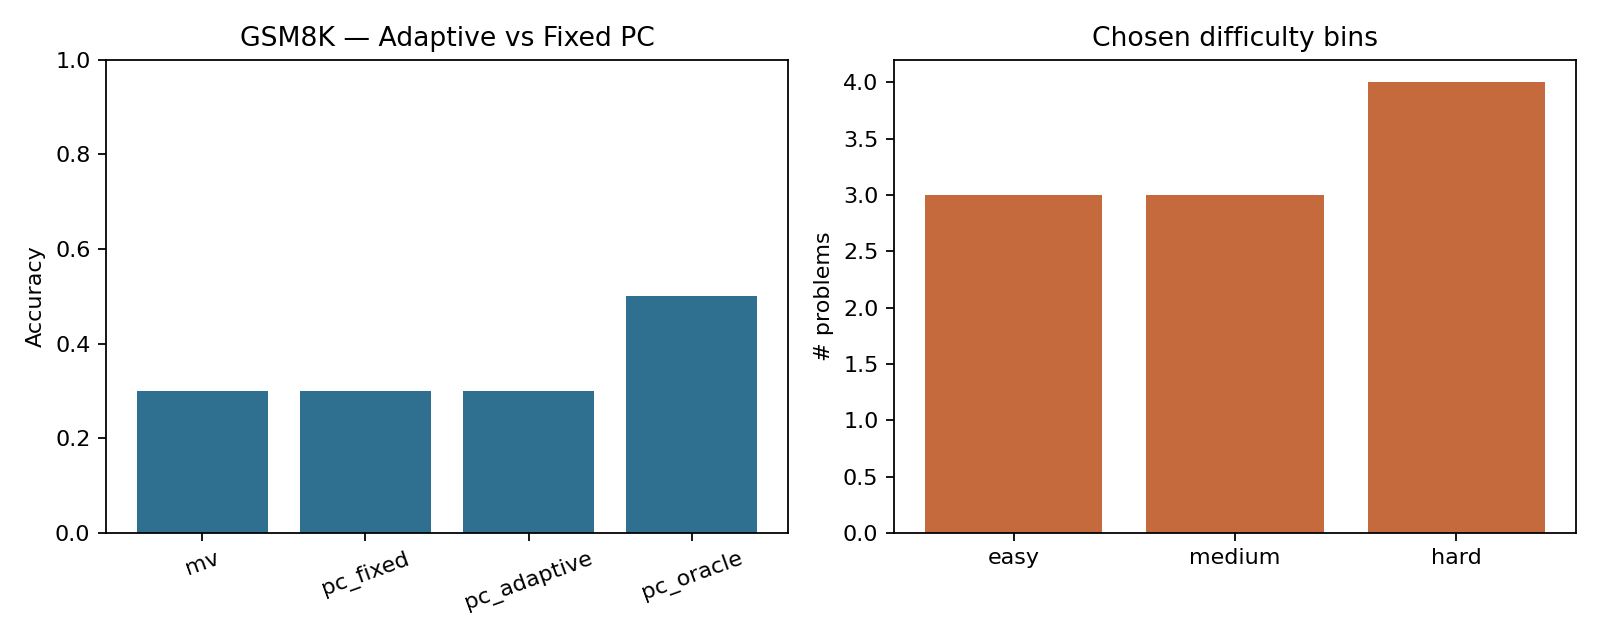

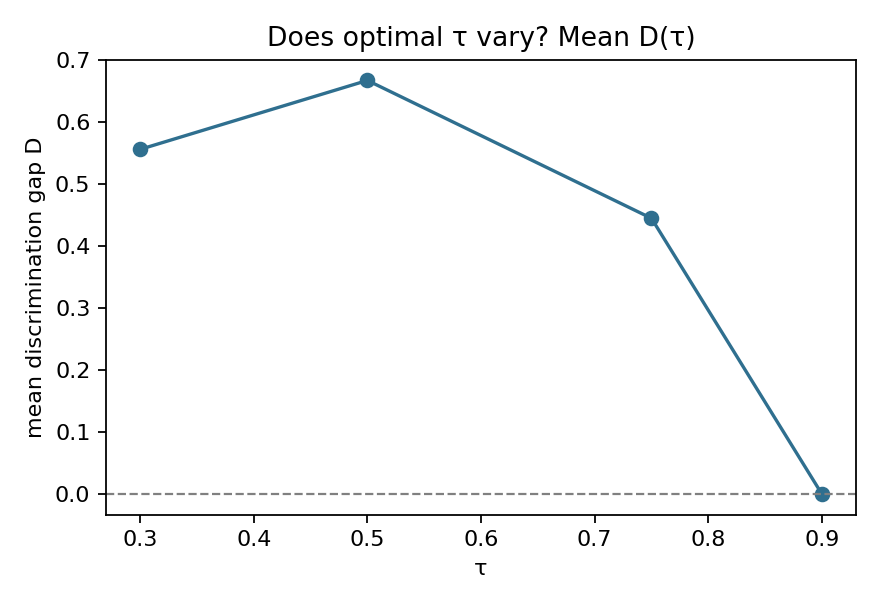

In [17]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

out = Path('outputs/gsm8k_qwen06b')
df = pd.read_csv(out / 'results.csv')
print(pd.read_csv(out / 'summary.csv'))
print('\nAdaptive τ counts:\n', df['adaptive_tau'].value_counts().sort_index())
print('\nDifficulty bins:\n', df['difficulty_label'].value_counts())

for name in ['summary.png', 'discrimination_gap_vs_tau.png']:
    p = out / name
    if p.exists():
        display(Image(filename=str(p)))

Loaded 10 rows from results.csv


### Summary table (paste into report)

,method,accuracy,mean_tokens
0,Majority Vote,0.3,1953.0
1,PC-WMV (τ=0.75),0.3,2696.5
2,PC-WMV (Adaptive τ),0.3,2705.8
3,PC-WMV (Oracle τ),0.5,3349.4


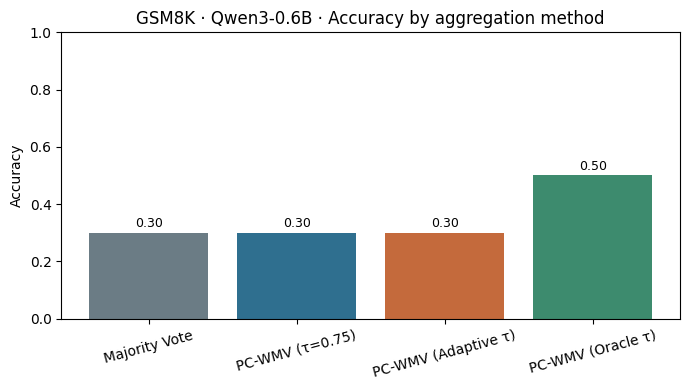

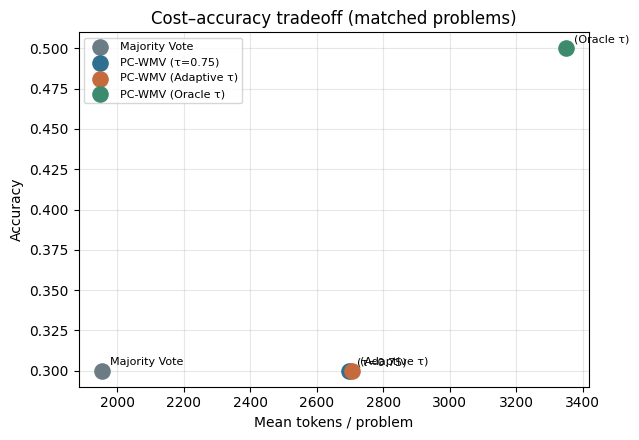

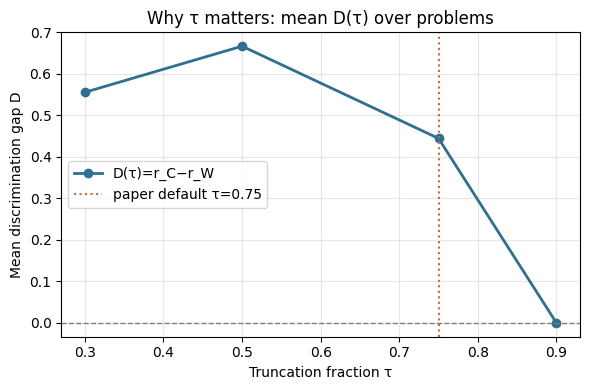

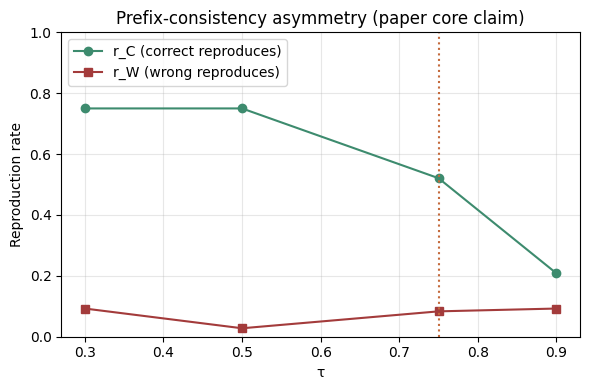

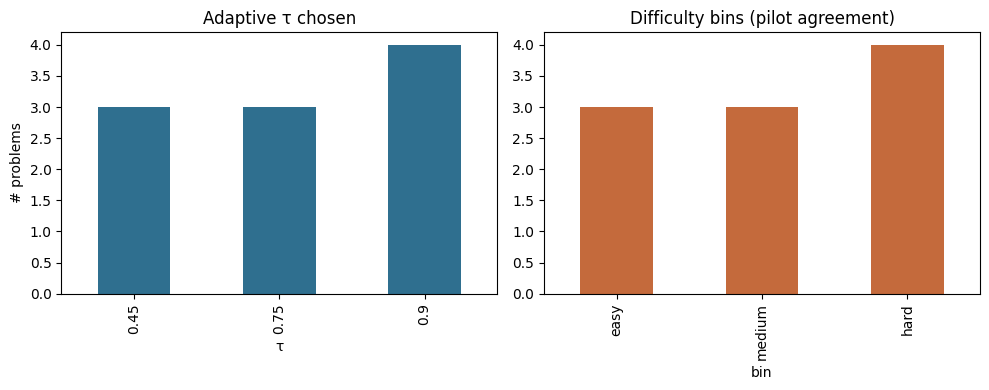

Problems where adaptive τ ≠ 0.75: 7 / 10
  fixed accuracy on those: 0.2857142857142857
  adaptive accuracy on those: 0.2857142857142857


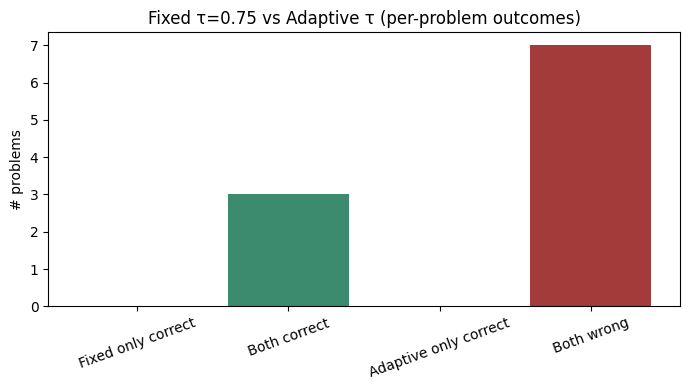


Saved plots to: /content/drive/MyDrive/adaptive-prefix-consistency/outputs/gsm8k_qwen06b/paper_plots


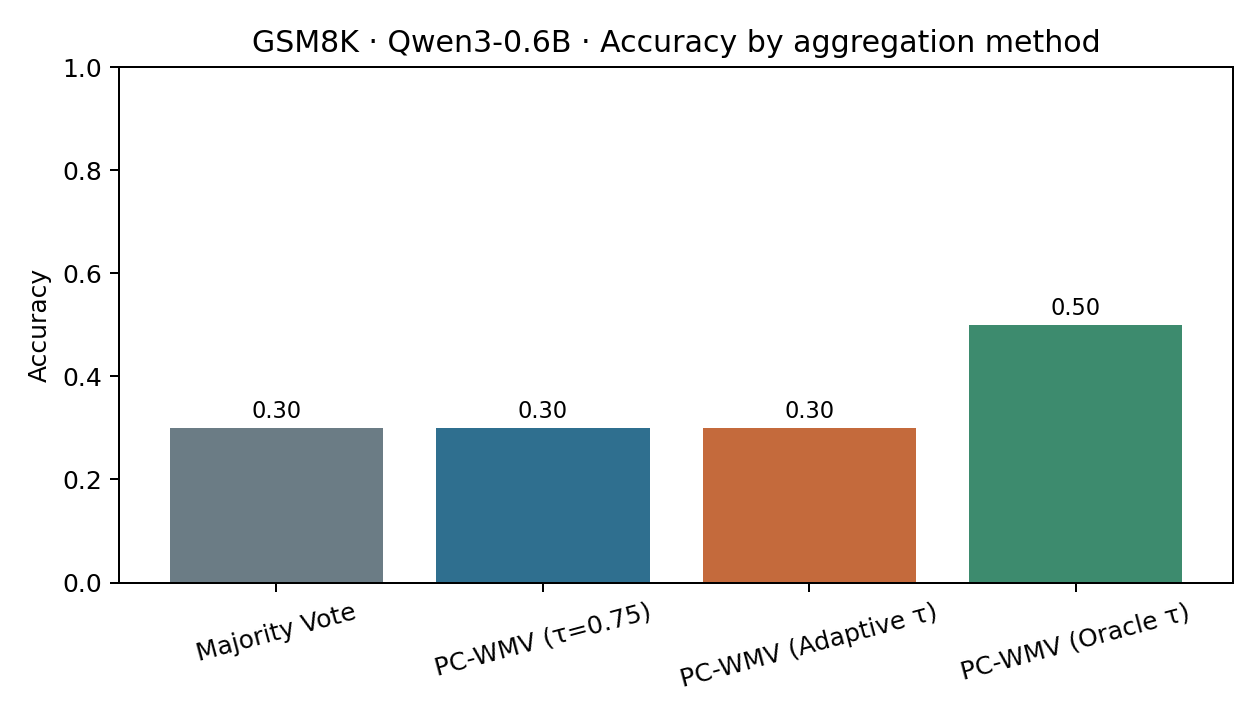

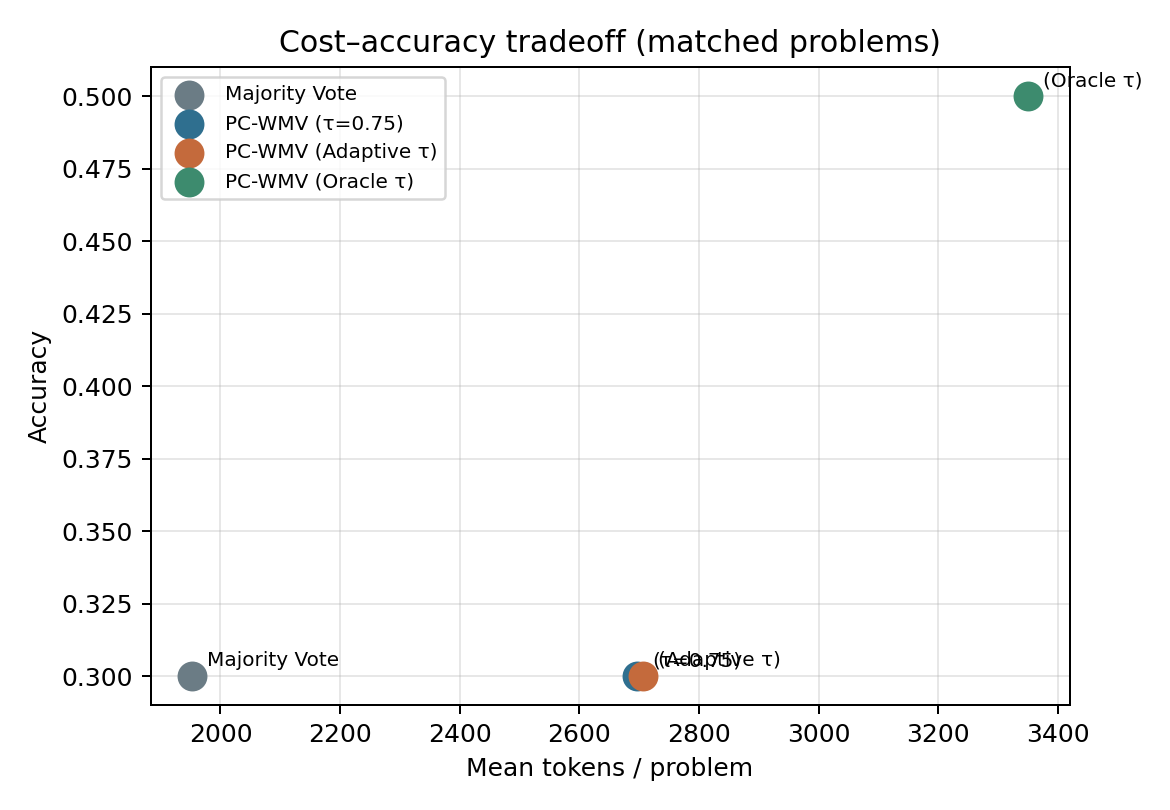

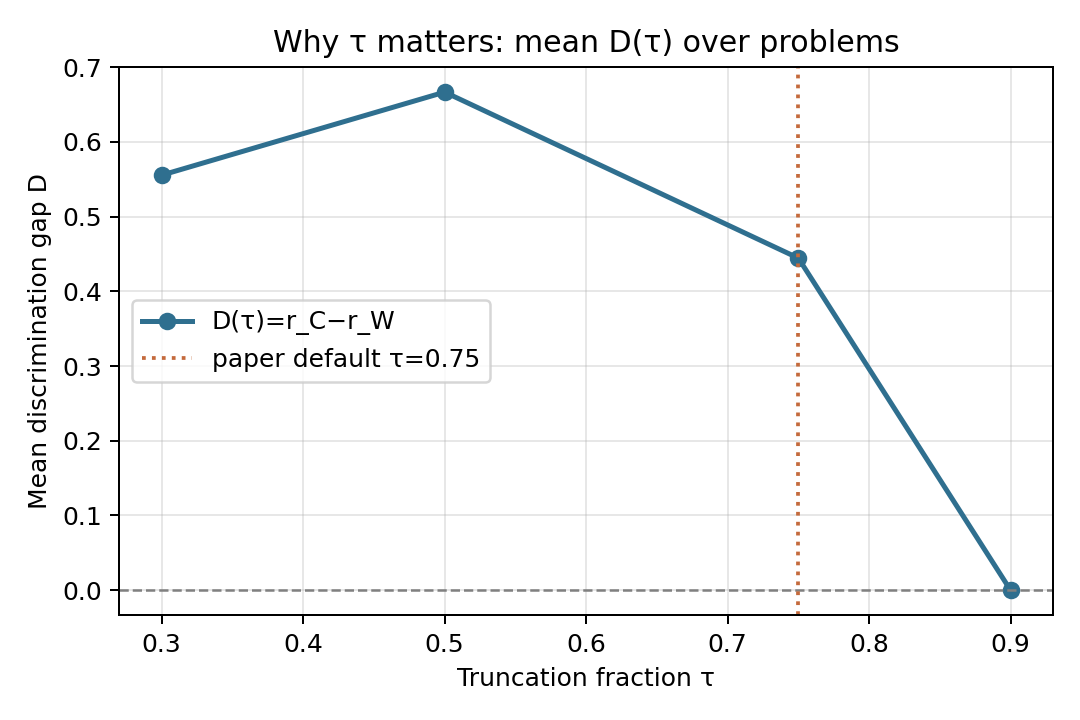

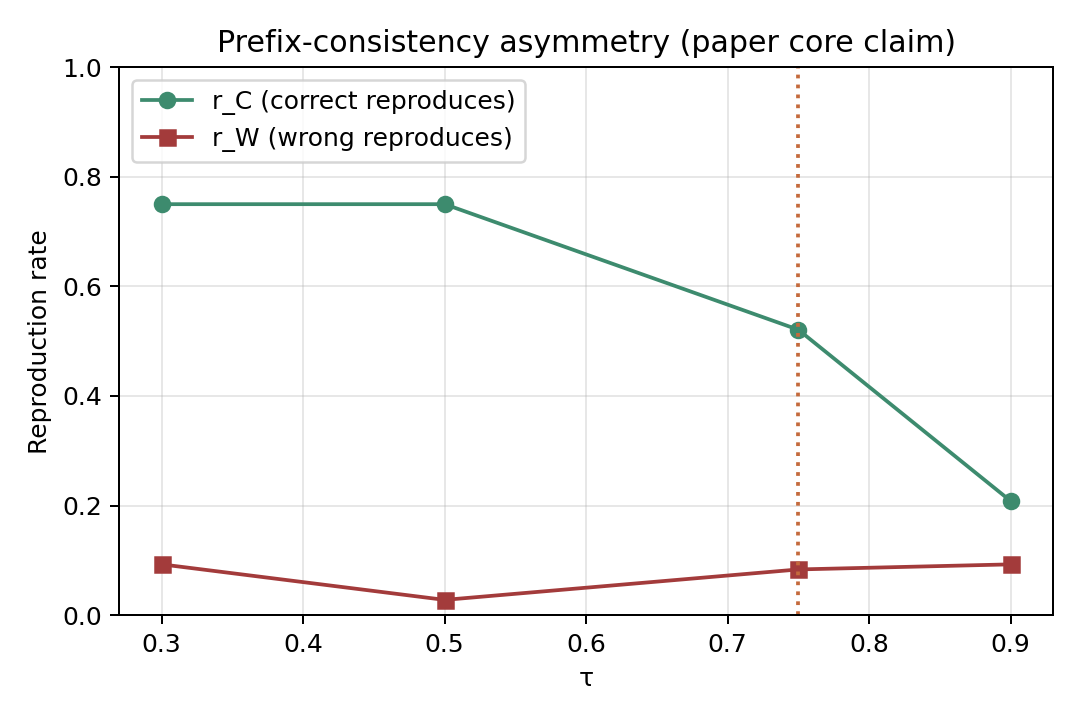

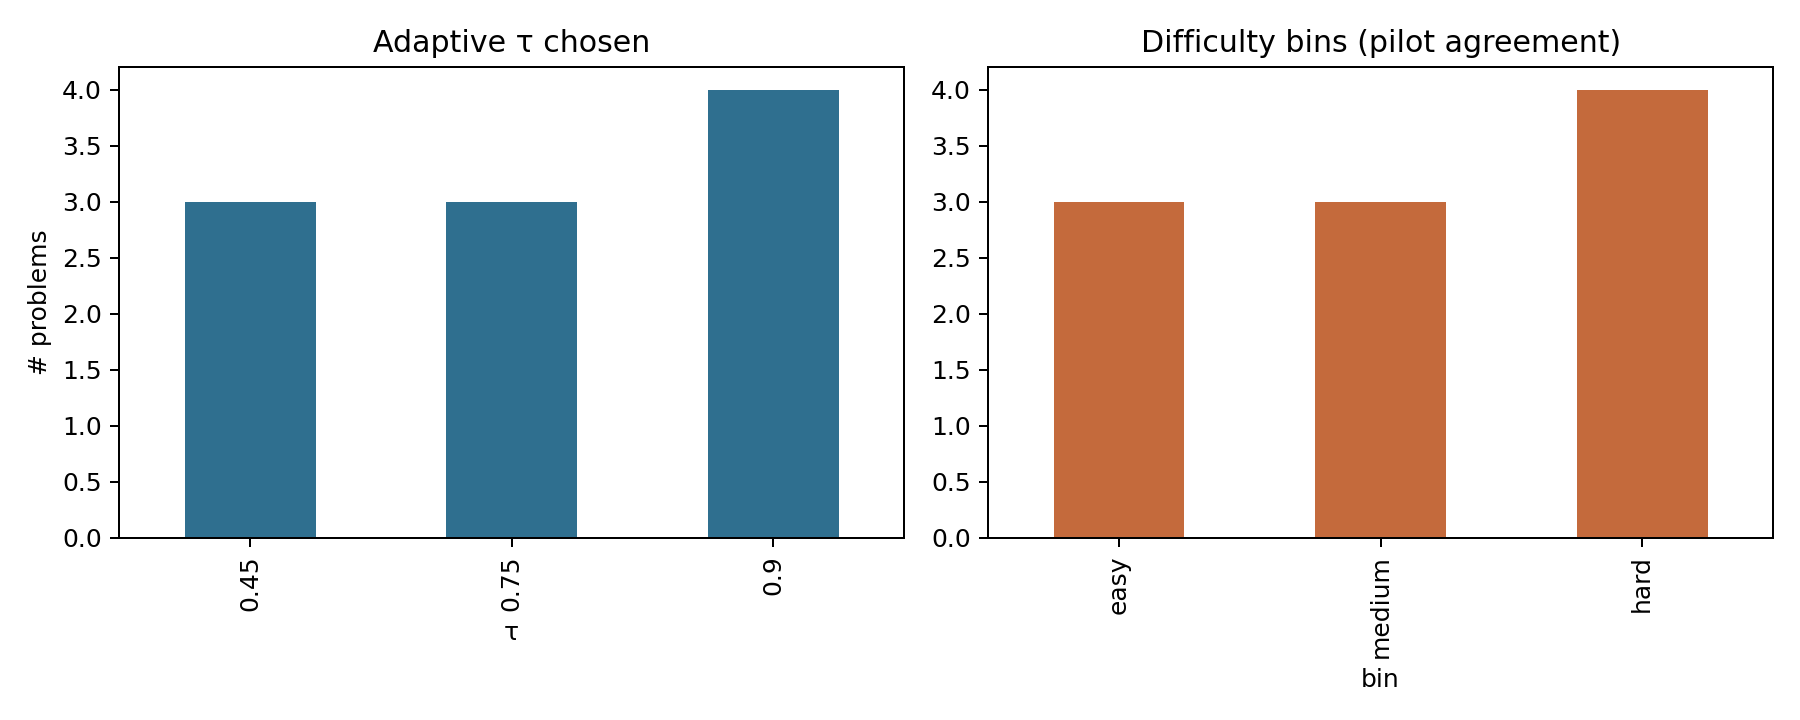

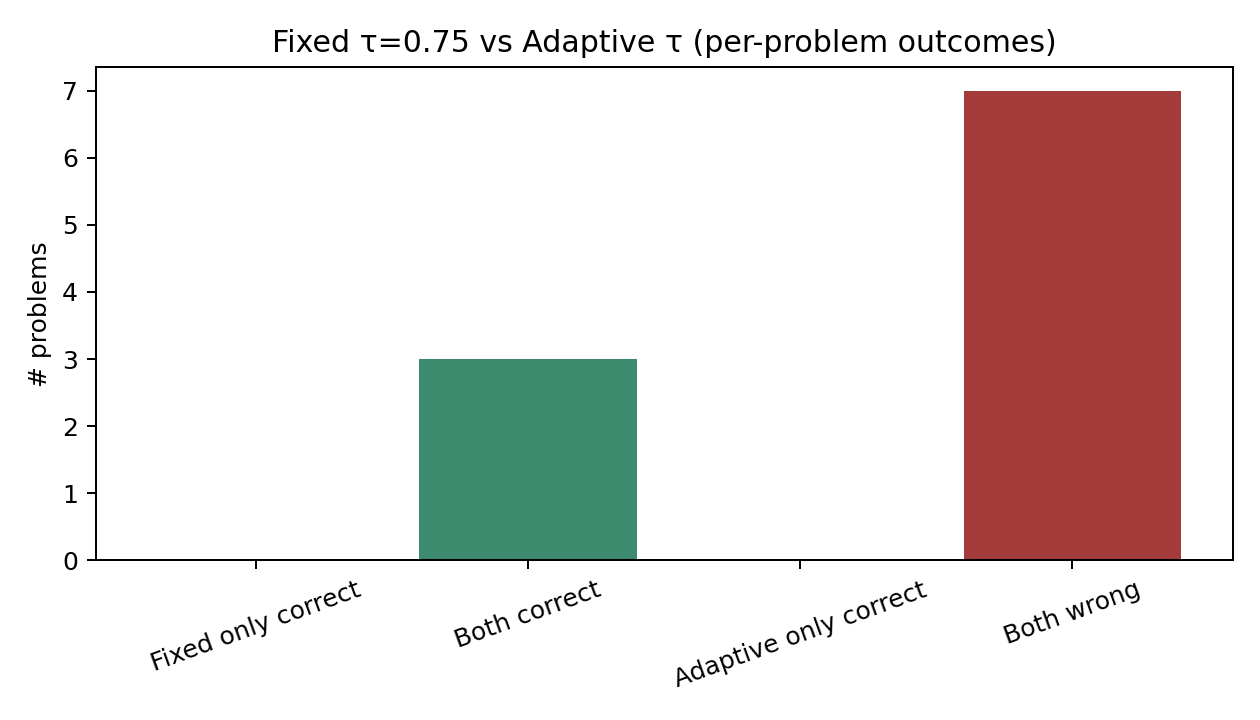

In [18]:

from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

OUT = Path("outputs/gsm8k_qwen06b")
OUT.mkdir(parents=True, exist_ok=True)
PLOT = OUT / "paper_plots"
PLOT.mkdir(exist_ok=True)

csv_path = OUT / "results.csv"
jsonl_path = OUT / "results.jsonl"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows from results.csv")
elif jsonl_path.exists():
    df = pd.read_json(jsonl_path, lines=True)
    print(f"Loaded {len(df)} rows from results.jsonl (checkpoint — run may be incomplete)")
else:
    raise FileNotFoundError(f"No results in {OUT}")

def norm(x):
    if pd.isna(x):
        return ""
    s = str(x).replace(",", "").replace("$", "").strip()
    nums = pd.Series(s).str.findall(r"-?\d+(?:\.\d+)?").iloc[0]
    return nums[-1] if nums else s.lower()

def acc(col):
    return float(np.mean([norm(p) == norm(g) for p, g in zip(df[col], df["gold"])]))

methods = [
    ("mv_pred", "mv_tokens", "Majority Vote"),
    ("pc_fixed_pred", "pc_fixed_tokens", "PC-WMV (τ=0.75)"),
    ("pc_adaptive_pred", "pc_adaptive_tokens", "PC-WMV (Adaptive τ)"),
    ("pc_oracle_pred", "pc_oracle_tokens", "PC-WMV (Oracle τ)"),
]

rows = []
for pred, tok, name in methods:
    if pred not in df.columns:
        continue
    rows.append({
        "method": name,
        "accuracy": acc(pred),
        "mean_tokens": float(df[tok].mean()) if tok in df.columns else np.nan,
    })
summary = pd.DataFrame(rows)
summary.to_csv(PLOT / "summary_table.csv", index=False)
display(Markdown("### Summary table (paste into report)"))
display(summary)

# ---------- Plot 1: Accuracy by method (paper-style bar) ----------
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#6B7C85", "#2F6F8F", "#C46A3C", "#3D8B6E"]
ax.bar(summary["method"], summary["accuracy"], color=colors[: len(summary)])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("GSM8K · Qwen3-0.6B · Accuracy by aggregation method")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(summary["accuracy"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(PLOT / "fig1_accuracy.png", dpi=180)
plt.show()

# Cost–accuracy
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for i, r in summary.iterrows():
    ax.scatter(r["mean_tokens"], r["accuracy"], s=120, color=colors[i], label=r["method"], zorder=3)
    ax.annotate(r["method"].replace("PC-WMV ", ""), (r["mean_tokens"], r["accuracy"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Mean tokens / problem")
ax.set_ylabel("Accuracy")
ax.set_title("Cost–accuracy tradeoff (matched problems)")
ax.legend(fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT / "fig2_cost_accuracy.png", dpi=180)
plt.show()

#  Discrimination gap D(tau)
d_cols = [c for c in df.columns if c.startswith("D_tau_")]
if d_cols:
    taus, d_means, rc_means, rw_means = [], [], [], []
    for c in sorted(d_cols, key=lambda x: float(x.split("_")[-1])):
        tau = float(c.split("_")[-1])
        taus.append(tau)
        d_means.append(df[c].astype(float).mean(skipna=True))
        rc_means.append(df[f"rC_tau_{tau}"].astype(float).mean(skipna=True))
        rw_means.append(df[f"rW_tau_{tau}"].astype(float).mean(skipna=True))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(taus, d_means, "o-", color="#2F6F8F", lw=2, label="D(τ)=r_C−r_W")
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.axvline(0.75, color="#C46A3C", ls=":", lw=1.5, label="paper default τ=0.75")
    ax.set_xlabel("Truncation fraction τ")
    ax.set_ylabel("Mean discrimination gap D")
    ax.set_title("Why τ matters: mean D(τ) over problems")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT / "fig3_discrimination_gap.png", dpi=180)
    plt.show()

    # r_C vs r_W
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(taus, rc_means, "o-", label="r_C (correct reproduces)", color="#3D8B6E")
    ax.plot(taus, rw_means, "s-", label="r_W (wrong reproduces)", color="#A33B3B")
    ax.axvline(0.75, color="#C46A3C", ls=":", lw=1.5)
    ax.set_xlabel("τ")
    ax.set_ylabel("Reproduction rate")
    ax.set_ylim(0, 1)
    ax.set_title("Prefix-consistency asymmetry (paper core claim)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT / "fig4_rC_rW.png", dpi=180)
    plt.show()

#Adaptive tau choices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["adaptive_tau"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2F6F8F")
axes[0].set_title("Adaptive τ chosen")
axes[0].set_xlabel("τ")
axes[0].set_ylabel("# problems")
df["difficulty_label"].value_counts().reindex(["easy", "medium", "hard"], fill_value=0).plot(
    kind="bar", ax=axes[1], color="#C46A3C"
)
axes[1].set_title("Difficulty bins (pilot agreement)")
axes[1].set_xlabel("bin")
fig.tight_layout()
fig.savefig(PLOT / "fig5_adaptive_tau_hist.png", dpi=180)
plt.show()

# ---------- Plot 6: Where adaptive ≠ fixed — win/lose ----------
same = df["adaptive_tau"] == df["fixed_tau"]
diff = ~same
fixed_ok = np.array([norm(p) == norm(g) for p, g in zip(df["pc_fixed_pred"], df["gold"])])
adapt_ok = np.array([norm(p) == norm(g) for p, g in zip(df["pc_adaptive_pred"], df["gold"])])

print("Problems where adaptive τ ≠ 0.75:", int(diff.sum()), "/", len(df))
if diff.sum() > 0:
    print("  fixed accuracy on those:", fixed_ok[diff].mean())
    print("  adaptive accuracy on those:", adapt_ok[diff].mean())

labels = ["Fixed only correct", "Both correct", "Adaptive only correct", "Both wrong"]
counts = [
    int(((fixed_ok) & (~adapt_ok)).sum()),
    int((fixed_ok & adapt_ok).sum()),
    int(((~fixed_ok) & (adapt_ok)).sum()),
    int(((~fixed_ok) & (~adapt_ok)).sum()),
]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts, color=["#6B7C85", "#3D8B6E", "#C46A3C", "#A33B3B"])
ax.set_ylabel("# problems")
ax.set_title("Fixed τ=0.75 vs Adaptive τ (per-problem outcomes)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(PLOT / "fig6_fixed_vs_adaptive_outcomes.png", dpi=180)
plt.show()

print("\nSaved plots to:", PLOT.resolve())
for p in sorted(PLOT.glob("fig*.png")):
    display(Image(filename=str(p)))


## Tips if T4 runs out of memory

1. Keep `Qwen/Qwen3-0.6B` (default).
2. Lower `max_new_tokens` to 384 in the YAML.
3. Set `enable_thinking: false` for shorter outputs.
4. For 1.5B/3B later: set `load_in_4bit: true`.

Loaded 10 problems from outputs/gsm8k_qwen06b


### Results table

,method,accuracy,mean_tokens
0,Majority Vote,0.3,1953.0
1,PC-WMV ($\tau{=}0.75$),0.3,2696.5
2,PC-WMV (Adaptive $\tau$),0.3,2705.8
3,PC-WMV (Oracle $\tau$),0.5,3349.4


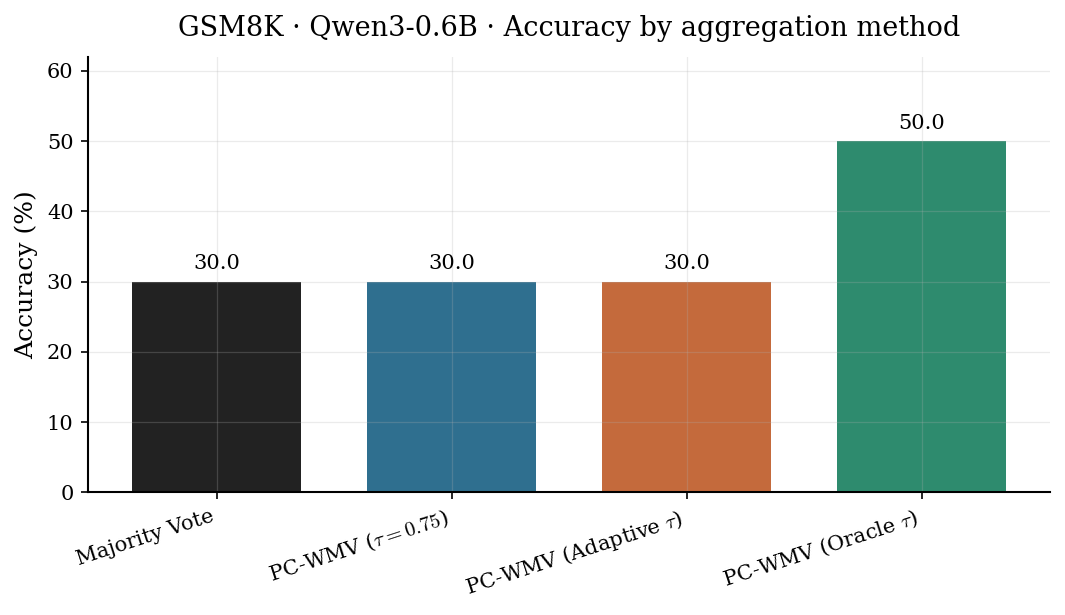

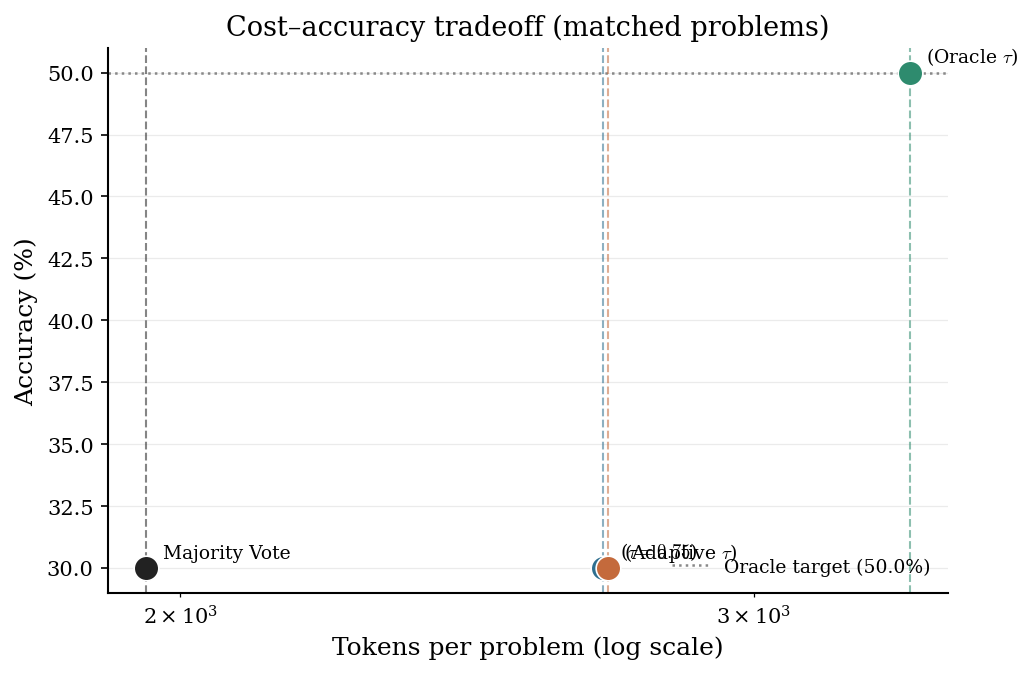

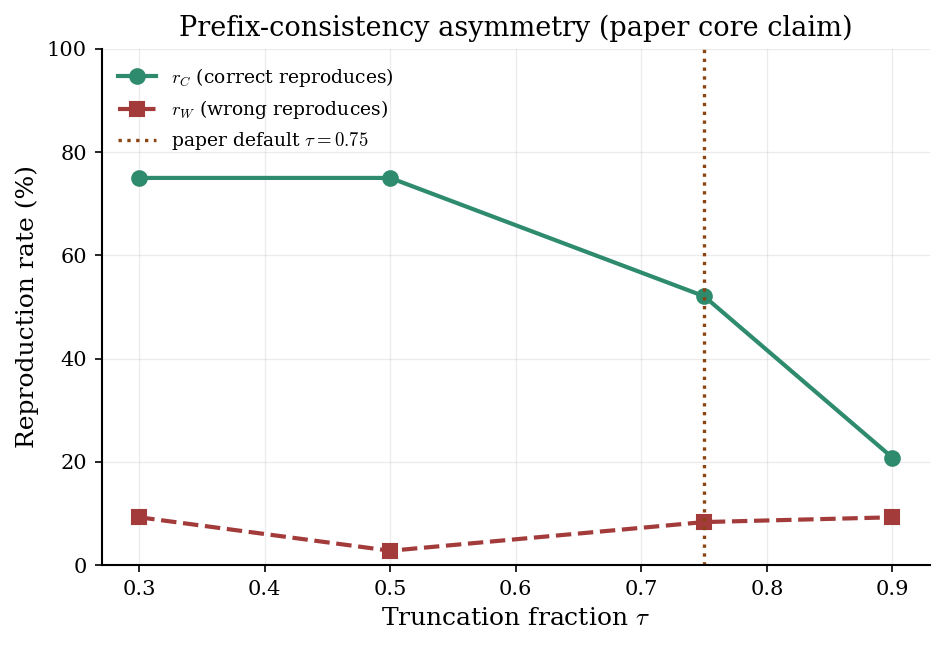

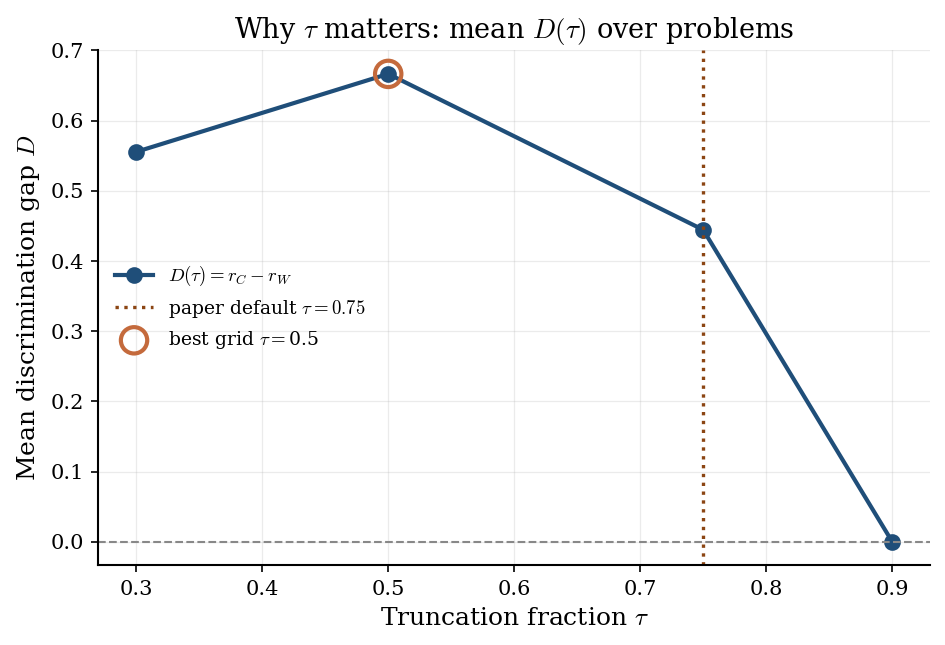

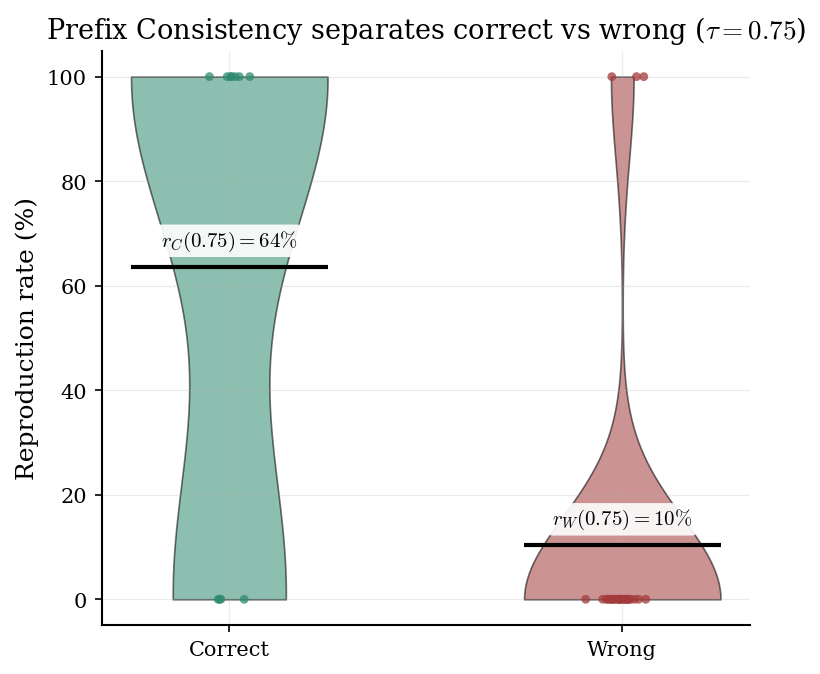

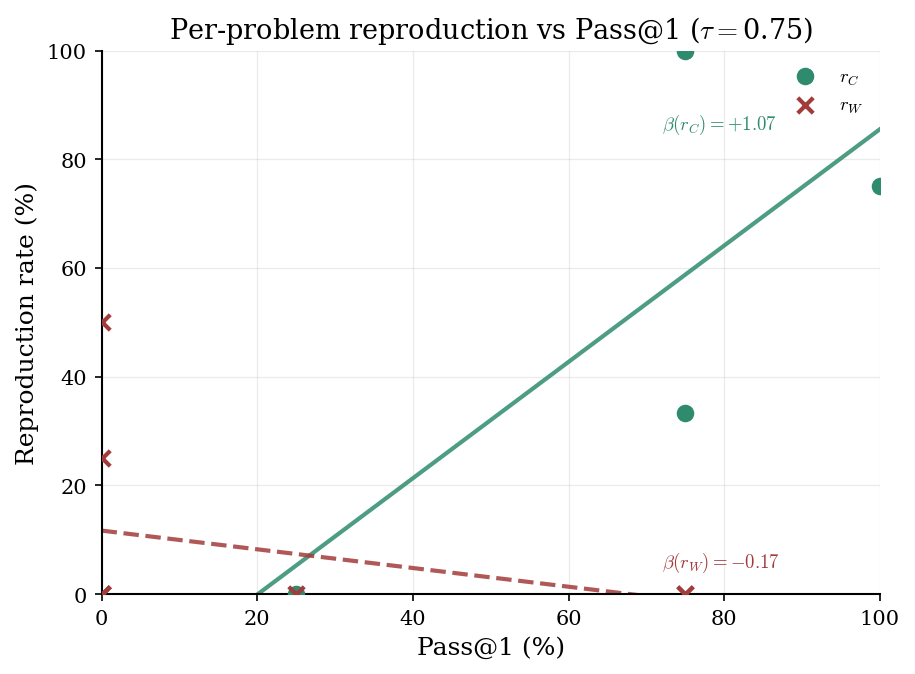

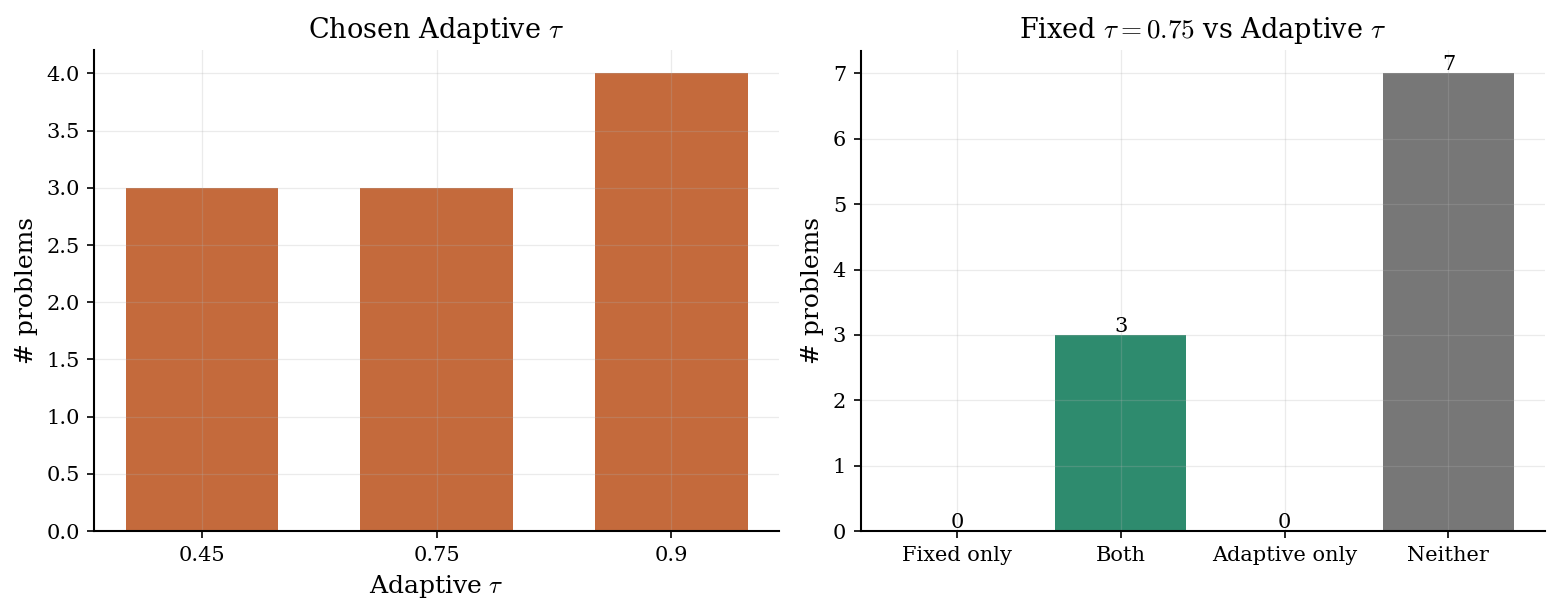

### Saved high-res PNG + PDF to `outputs/gsm8k_qwen06b/paper_plots_hires`

Files:
  figA_accuracy_bars.pdf
  figA_accuracy_bars.png
  figB_cost_accuracy.pdf
  figB_cost_accuracy.png
  figC_rC_rW.pdf
  figC_rC_rW.png
  figD_discrimination_gap.pdf
  figD_discrimination_gap.png
  figE_pc_violin.pdf
  figE_pc_violin.png
  figF_pass1_vs_reproduction.pdf
  figF_pass1_vs_reproduction.png
  figG_adaptive_outcomes.pdf
  figG_adaptive_outcomes.png


In [24]:

from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, Markdown

# =========================
# Style (paper-like)
# =========================
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.0,
    "lines.markersize": 7,
})

C_MV = "#222222"
C_FIXED = "#2F6F8F"
C_ADAPT = "#C46A3C"
C_ORACLE = "#2E8B6E"
C_RC = "#2E8B6E"
C_RW = "#A33B3B"
C_D = "#1F4E79"
C_TAU = "#8B4513"

OUT = Path("outputs/gsm8k_qwen06b")
for cand in [OUT, Path("outputs/gsm8k_qwen3_06b"), Path("outputs/gsm8k_qwen06b_fast")]:
    if (cand / "results.csv").exists() or (cand / "results.jsonl").exists():
        OUT = cand
        break

PLOT = OUT / "paper_plots_hires"
PLOT.mkdir(parents=True, exist_ok=True)

if (OUT / "results.csv").exists():
    df = pd.read_csv(OUT / "results.csv")
else:
    df = pd.read_json(OUT / "results.jsonl", lines=True)

print("Loaded {} problems from {}".format(len(df), OUT))


def norm(x):
    if pd.isna(x):
        return ""
    s = str(x).replace(",", "").replace("$", "").strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", s)
    return nums[-1] if nums else s.lower()


def is_correct(pred, gold):
    return norm(pred) == norm(gold) and norm(pred) != ""


def parse_list(cell):
    if isinstance(cell, list):
        return cell
    if pd.isna(cell):
        return []
    try:
        return ast.literal_eval(str(cell))
    except Exception:
        return []


def method_table(frame):
    specs = [
        ("mv_pred", "mv_tokens", r"Majority Vote", C_MV),
        ("pc_fixed_pred", "pc_fixed_tokens", r"PC-WMV ($\tau{=}0.75$)", C_FIXED),
        ("pc_adaptive_pred", "pc_adaptive_tokens", r"PC-WMV (Adaptive $\tau$)", C_ADAPT),
        ("pc_oracle_pred", "pc_oracle_tokens", r"PC-WMV (Oracle $\tau$)", C_ORACLE),
    ]
    rows = []
    for pred, tok, name, color in specs:
        if pred not in frame.columns:
            continue
        ok = np.mean([is_correct(p, g) for p, g in zip(frame[pred], frame["gold"])])
        mt = float(frame[tok].mean()) if tok in frame.columns else np.nan
        rows.append({"pred": pred, "method": name, "accuracy": ok, "mean_tokens": mt, "color": color})
    return pd.DataFrame(rows)


summary = method_table(df)
summary.to_csv(PLOT / "summary_table.csv", index=False)
display(Markdown("### Results table"))
display(summary[["method", "accuracy", "mean_tokens"]])

# ---------- FIG A ----------
fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(summary))
bars = ax.bar(x, summary["accuracy"] * 100, color=summary["color"], width=0.72, edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(summary["method"], rotation=18, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, max(55, float(summary["accuracy"].max()) * 100 + 12))
ax.set_title("GSM8K · Qwen3-0.6B · Accuracy by aggregation method", pad=10)
for b, v in zip(bars, summary["accuracy"] * 100):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, "{:.1f}".format(v),
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()
fig.savefig(PLOT / "figA_accuracy_bars.png", bbox_inches="tight")
fig.savefig(PLOT / "figA_accuracy_bars.pdf", bbox_inches="tight")
plt.show()

# ---------- FIG B ----------
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for _, r in summary.iterrows():
    ax.scatter(r["mean_tokens"], r["accuracy"] * 100, s=140, color=r["color"],
               zorder=4, edgecolors="white", linewidths=0.8)
    ax.annotate(r["method"].replace("PC-WMV ", ""),
                (r["mean_tokens"], r["accuracy"] * 100),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Tokens per problem (log scale)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Cost–accuracy tradeoff (matched problems)")

if len(summary):
    if "pc_oracle_pred" in set(summary["pred"]):
        target = float(summary.loc[summary["pred"] == "pc_oracle_pred", "accuracy"].values[0]) * 100
    else:
        target = float(summary["accuracy"].max()) * 100
    ax.axhline(target, color="#888888", ls=":", lw=1.2,
               label="Oracle target ({:.1f}%)".format(target))

for _, r in summary.iterrows():
    ax.axvline(r["mean_tokens"], color=r["color"], ls="--", lw=1.0, alpha=0.55)

ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(PLOT / "figB_cost_accuracy.png", bbox_inches="tight")
fig.savefig(PLOT / "figB_cost_accuracy.pdf", bbox_inches="tight")
plt.show()

# ---------- tau grid stats ----------
d_cols = sorted(
    [c for c in df.columns if c.startswith("D_tau_")],
    key=lambda c: float(c.split("_")[-1]),
)
taus, d_m, rc_m, rw_m = [], [], [], []
for c in d_cols:
    tau = float(c.split("_")[-1])
    taus.append(tau)
    d_m.append(df[c].astype(float).mean(skipna=True))
    rc_m.append(df["rC_tau_{}".format(tau)].astype(float).mean(skipna=True))
    rw_m.append(df["rW_tau_{}".format(tau)].astype(float).mean(skipna=True))

# ---------- FIG C ----------
if taus:
    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    ax.plot(taus, np.array(rc_m) * 100, "o-", color=C_RC, label=r"$r_C$ (correct reproduces)")
    ax.plot(taus, np.array(rw_m) * 100, "s--", color=C_RW, label=r"$r_W$ (wrong reproduces)")
    ax.axvline(0.75, color=C_TAU, ls=":", lw=1.6, label=r"paper default $\tau{=}0.75$")
    ax.set_xlabel(r"Truncation fraction $\tau$")
    ax.set_ylabel("Reproduction rate (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Prefix-consistency asymmetry (paper core claim)")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    fig.savefig(PLOT / "figC_rC_rW.png", bbox_inches="tight")
    fig.savefig(PLOT / "figC_rC_rW.pdf", bbox_inches="tight")
    plt.show()

# ---------- FIG D ----------
if taus:
    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    ax.plot(taus, d_m, "o-", color=C_D, label=r"$D(\tau)=r_C-r_W$")
    ax.axhline(0.0, color="#888888", ls="--", lw=1.0)
    ax.axvline(0.75, color=C_TAU, ls=":", lw=1.6, label=r"paper default $\tau{=}0.75$")
    best_i = int(np.nanargmax(d_m))
    best_tau = taus[best_i]
    ax.scatter([best_tau], [d_m[best_i]], s=160, facecolors="none",
               edgecolors=C_ADAPT, linewidths=2.0, zorder=5,
               label=r"best grid $\tau{=}$" + str(best_tau))
    ax.set_xlabel(r"Truncation fraction $\tau$")
    ax.set_ylabel(r"Mean discrimination gap $D$")
    ax.set_title(r"Why $\tau$ matters: mean $D(\tau)$ over problems")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    fig.savefig(PLOT / "figD_discrimination_gap.png", bbox_inches="tight")
    fig.savefig(PLOT / "figD_discrimination_gap.pdf", bbox_inches="tight")
    plt.show()

# ---------- FIG E ----------
correct_scores, wrong_scores = [], []
if "fixed_regens" in df.columns and "original_answers" in df.columns:
    for _, row in df.iterrows():
        gold = norm(row["gold"])
        origs = parse_list(row["original_answers"])
        regs = parse_list(row["fixed_regens"])
        for o, r in zip(origs, regs):
            o_n, r_n = norm(o), norm(r)
            if not o_n:
                continue
            score = 100.0 if (o_n == r_n) else 0.0
            if o_n == gold:
                correct_scores.append(score)
            else:
                wrong_scores.append(score)

if correct_scores and wrong_scores:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    data = [correct_scores, wrong_scores]
    parts = ax.violinplot(data, positions=[0, 1], showmeans=False, showmedians=False, showextrema=False)
    for i, b in enumerate(parts["bodies"]):
        b.set_facecolor([C_RC, C_RW][i])
        b.set_alpha(0.55)
        b.set_edgecolor("black")
        b.set_linewidth(0.8)

    rng = np.random.default_rng(0)
    for i, vals in enumerate(data):
        vals = np.asarray(vals, dtype=float)
        ax.scatter(i + rng.normal(0, 0.04, size=len(vals)), vals,
                   s=18, color=[C_RC, C_RW][i], alpha=0.75, zorder=3, edgecolors="none")

    rc = float(np.mean(correct_scores))
    rw = float(np.mean(wrong_scores))
    ax.hlines(rc, -0.25, 0.25, colors="black", lw=2)
    ax.hlines(rw, 0.75, 1.25, colors="black", lw=2)
    ax.text(0.0, min(100, rc + 4),
            r"$r_C(0.75)={:.0f}\%$".format(rc),
            ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))
    ax.text(1.0, max(0, rw + 4),
            r"$r_W(0.75)={:.0f}\%$".format(rw),
            ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Correct", "Wrong"])
    ax.set_ylabel("Reproduction rate (%)")
    ax.set_ylim(-5, 105)
    ax.set_title(r"Prefix Consistency separates correct vs wrong ($\tau{=}0.75$)")
    fig.tight_layout()
    fig.savefig(PLOT / "figE_pc_violin.png", bbox_inches="tight")
    fig.savefig(PLOT / "figE_pc_violin.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Skipping violin (need original_answers + fixed_regens columns).")

# ---------- FIG F ----------
if "pass_at_1" in df.columns and d_cols:
    tau_use = 0.75 if "rC_tau_0.75" in df.columns else float(taus[len(taus) // 2])
    rc_col = "rC_tau_{}".format(tau_use)
    rw_col = "rW_tau_{}".format(tau_use)
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    x = df["pass_at_1"].astype(float) * 100
    y_c = df[rc_col].astype(float) * 100
    y_w = df[rw_col].astype(float) * 100
    m_c = np.isfinite(y_c)
    m_w = np.isfinite(y_w)
    ax.scatter(x[m_c], y_c[m_c], c=C_RC, s=55, marker="o", label=r"$r_C$", zorder=3)
    ax.scatter(x[m_w], y_w[m_w], c=C_RW, s=55, marker="x", label=r"$r_W$", zorder=3)

    def _fit(xx, yy):
        xx, yy = np.asarray(xx), np.asarray(yy)
        m = np.isfinite(xx) & np.isfinite(yy)
        if m.sum() < 2:
            return None
        coef = np.polyfit(xx[m], yy[m], 1)
        xs = np.linspace(0, 100, 50)
        return xs, coef[0] * xs + coef[1], coef[0]

    fit_c = _fit(x[m_c], y_c[m_c])
    fit_w = _fit(x[m_w], y_w[m_w])
    if fit_c is not None:
        ax.plot(fit_c[0], fit_c[1], "-", color=C_RC, alpha=0.85)
        beta_c = fit_c[2]
        ax.text(72, min(95, fit_c[1][-1]),
                r"$\beta(r_C)={:+.2f}$".format(beta_c),
                color=C_RC, fontsize=9)
    if fit_w is not None:
        ax.plot(fit_w[0], fit_w[1], "--", color=C_RW, alpha=0.85)
        beta_w = fit_w[2]
        ax.text(72, max(5, fit_w[1][-1]),
                r"$\beta(r_W)={:+.2f}$".format(beta_w),
                color=C_RW, fontsize=9)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Pass@1 (%)")
    ax.set_ylabel("Reproduction rate (%)")
    ax.set_title(r"Per-problem reproduction vs Pass@1 ($\tau{=}$" + str(tau_use) + ")")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    fig.savefig(PLOT / "figF_pass1_vs_reproduction.png", bbox_inches="tight")
    fig.savefig(PLOT / "figF_pass1_vs_reproduction.pdf", bbox_inches="tight")
    plt.show()

# ---------- FIG G ----------
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
tau_counts = df["adaptive_tau"].value_counts().sort_index()
axes[0].bar([str(t) for t in tau_counts.index], tau_counts.values, color=C_ADAPT, width=0.65)
axes[0].set_xlabel(r"Adaptive $\tau$")
axes[0].set_ylabel("# problems")
axes[0].set_title(r"Chosen Adaptive $\tau$")

fixed_ok = np.array([is_correct(p, g) for p, g in zip(df["pc_fixed_pred"], df["gold"])])
adapt_ok = np.array([is_correct(p, g) for p, g in zip(df["pc_adaptive_pred"], df["gold"])])
labels = ["Fixed only", "Both", "Adaptive only", "Neither"]
counts = [
    int((fixed_ok & ~adapt_ok).sum()),
    int((fixed_ok & adapt_ok).sum()),
    int((~fixed_ok & adapt_ok).sum()),
    int((~fixed_ok & ~adapt_ok).sum()),
]
axes[1].bar(labels, counts, color=[C_FIXED, C_ORACLE, C_ADAPT, "#777777"])
axes[1].set_ylabel("# problems")
axes[1].set_title(r"Fixed $\tau{=}0.75$ vs Adaptive $\tau$")
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.05, str(v), ha="center")
fig.tight_layout()
fig.savefig(PLOT / "figG_adaptive_outcomes.png", bbox_inches="tight")
fig.savefig(PLOT / "figG_adaptive_outcomes.pdf", bbox_inches="tight")
plt.show()

display(Markdown("### Saved high-res PNG + PDF to `{}`".format(PLOT)))
print("Files:")
for p in sorted(PLOT.glob("fig*")):
    print(" ", p.name)


In [21]:
from google.colab import files
from pathlib import Path

out = Path('/content/drive/MyDrive/adaptive-prefix-consistency/outputs/gsm8k_qwen06b')

for name in ['results.jsonl', 'results.csv', 'summary.csv', 'summary.png',
             'discrimination_gap_vs_tau.png']:
    p = out / name
    if p.exists():
        files.download(str(p))
        print('Downloading', p.name)
    else:
        print('Missing:', name)

# download paper plots folder if present
for folder in ['paper_plots', 'paper_plots_hires']:
    d = out / folder
    if d.exists():
        for p in d.glob('*'):
            if p.is_file():
                files.download(str(p))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

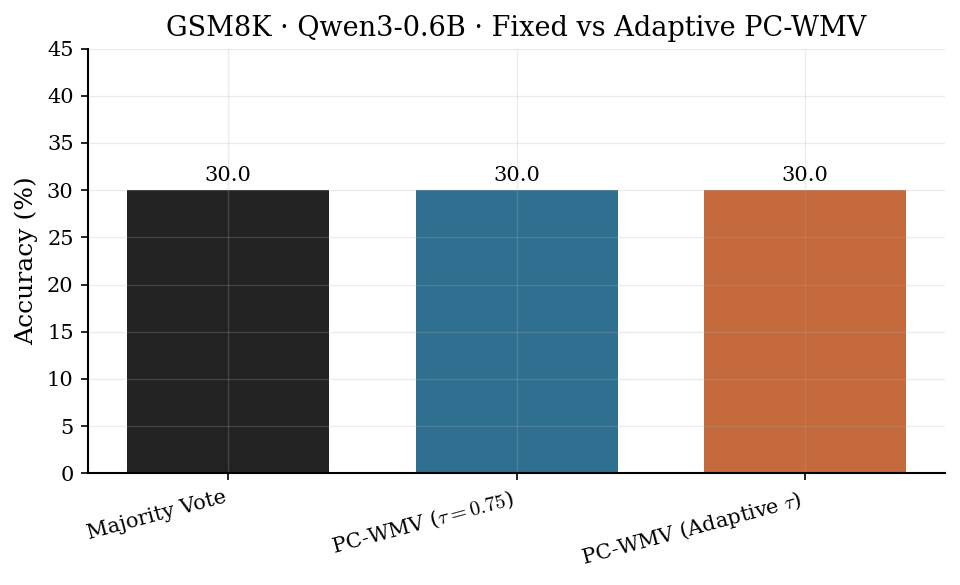

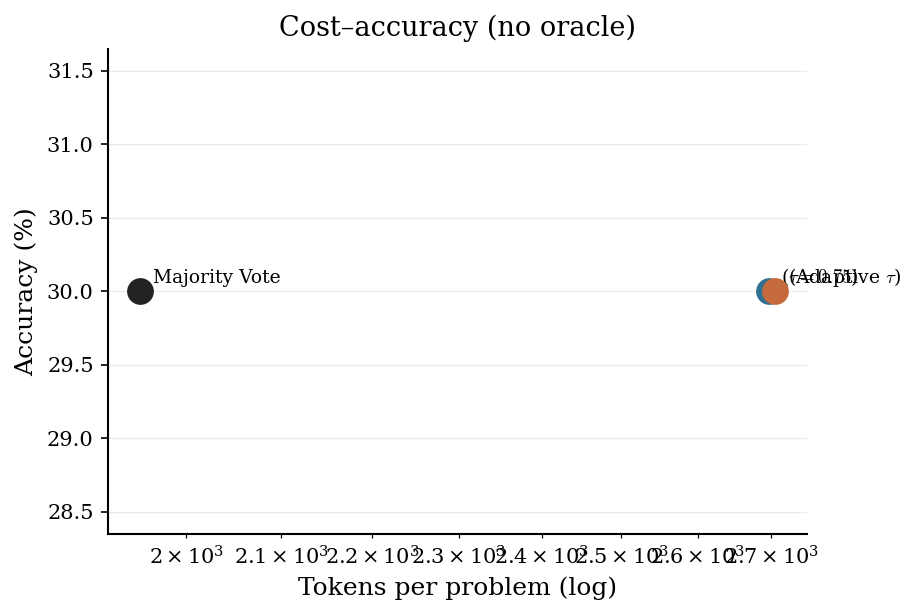

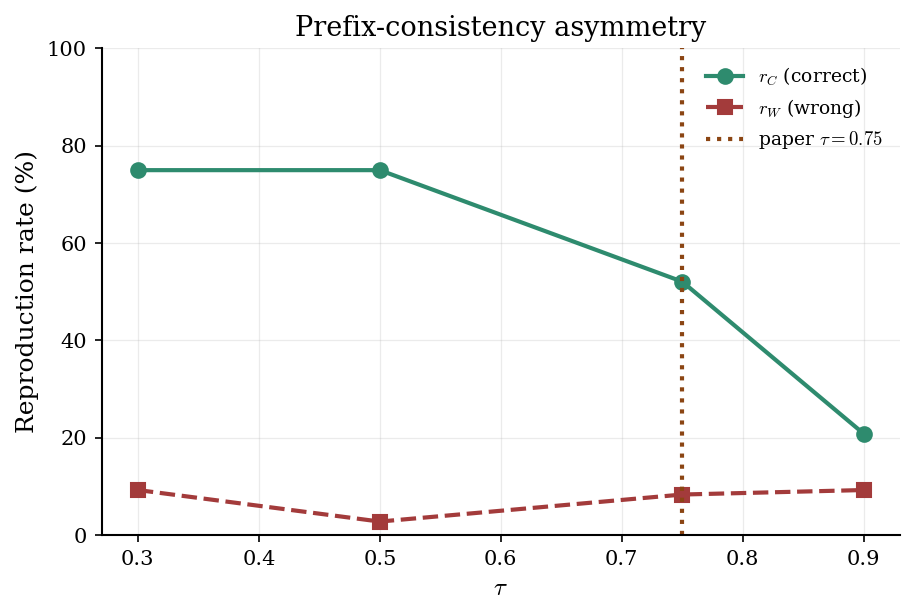

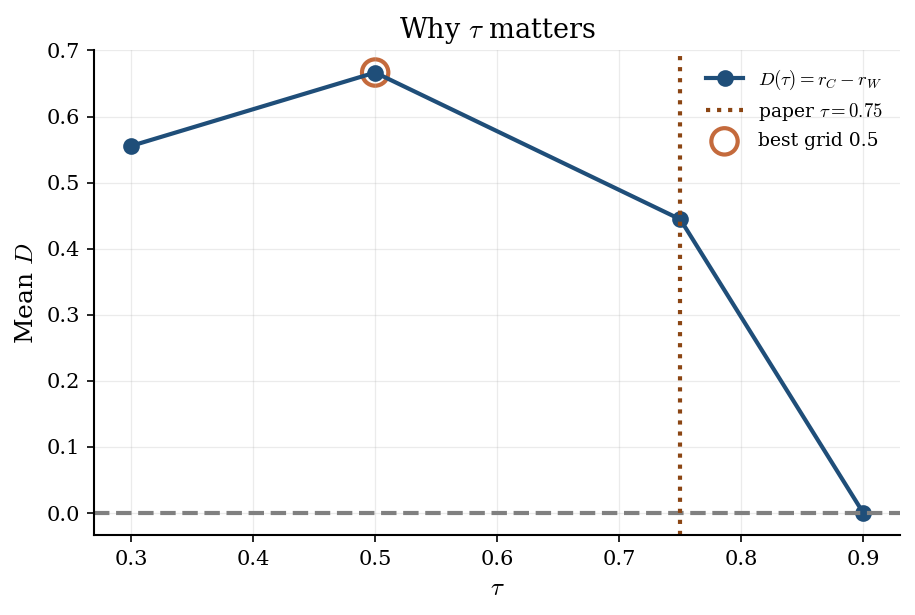

Saved to outputs/gsm8k_qwen06b/paper_plots_no_oracle
MV / Fixed / Adaptive accuracy: [np.float64(30.0), np.float64(30.0), np.float64(30.0)]
Mean tokens: [1953.0, 2696.5, 2705.8]


In [25]:
from pathlib import Path
import ast, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "serif", "mathtext.fontset": "cm",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

C_MV, C_FIXED, C_ADAPT = "#222222", "#2F6F8F", "#C46A3C"
C_RC, C_RW, C_D, C_TAU = "#2E8B6E", "#A33B3B", "#1F4E79", "#8B4513"

OUT = Path("outputs/gsm8k_qwen06b")
PLOT = OUT / "paper_plots_no_oracle"
PLOT.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(OUT / "results.csv") if (OUT / "results.csv").exists() else pd.read_json(OUT / "results.jsonl", lines=True)

def norm(x):
    if pd.isna(x): return ""
    nums = re.findall(r"-?\d+(?:\.\d+)?", str(x).replace(",", "").replace("$", ""))
    return nums[-1] if nums else str(x).lower().strip()

def ok(pred, gold): return norm(pred) == norm(gold) and norm(pred) != ""

# --- only these three methods (NO oracle) ---
methods = [
    ("mv_pred", "mv_tokens", "Majority Vote", C_MV),
    ("pc_fixed_pred", "pc_fixed_tokens", r"PC-WMV ($\tau{=}0.75$)", C_FIXED),
    ("pc_adaptive_pred", "pc_adaptive_tokens", r"PC-WMV (Adaptive $\tau$)", C_ADAPT),
]
accs, toks, names, colors = [], [], [], []
for pred, tok, name, col in methods:
    accs.append(100 * np.mean([ok(p, g) for p, g in zip(df[pred], df["gold"])]))
    toks.append(float(df[tok].mean()))
    names.append(name); colors.append(col)

# Fig 1: accuracy
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(range(3), accs, color=colors, width=0.7)
ax.set_xticks(range(3)); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, max(accs) + 15)
ax.set_title("GSM8K · Qwen3-0.6B · Fixed vs Adaptive PC-WMV")
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 1, "{:.1f}".format(v), ha="center")
fig.tight_layout(); fig.savefig(PLOT / "acc_no_oracle.png", bbox_inches="tight"); plt.show()

# Fig 2: cost–accuracy
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for t, a, n, c in zip(toks, accs, names, colors):
    ax.scatter(t, a, s=140, color=c, zorder=3)
    ax.annotate(n.replace("PC-WMV ", ""), (t, a), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("Tokens per problem (log)"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Cost–accuracy (no oracle)")
fig.tight_layout(); fig.savefig(PLOT / "cost_acc_no_oracle.png", bbox_inches="tight"); plt.show()

# Fig 3–4: r_C, r_W, D(τ)
taus = sorted(float(c.split("_")[-1]) for c in df.columns if c.startswith("D_tau_"))
rc = [df["rC_tau_{}".format(t)].astype(float).mean(skipna=True) * 100 for t in taus]
rw = [df["rW_tau_{}".format(t)].astype(float).mean(skipna=True) * 100 for t in taus]
Dd = [df["D_tau_{}".format(t)].astype(float).mean(skipna=True) for t in taus]

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(taus, rc, "o-", color=C_RC, label=r"$r_C$ (correct)")
ax.plot(taus, rw, "s--", color=C_RW, label=r"$r_W$ (wrong)")
ax.axvline(0.75, color=C_TAU, ls=":", label=r"paper $\tau{=}0.75$")
ax.set_ylim(0, 100); ax.set_xlabel(r"$\tau$"); ax.set_ylabel("Reproduction rate (%)")
ax.set_title("Prefix-consistency asymmetry"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(PLOT / "rC_rW.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(taus, Dd, "o-", color=C_D, label=r"$D(\tau)=r_C-r_W$")
ax.axhline(0, color="gray", ls="--"); ax.axvline(0.75, color=C_TAU, ls=":", label=r"paper $\tau{=}0.75$")
bi = int(np.nanargmax(Dd))
ax.scatter([taus[bi]], [Dd[bi]], s=160, facecolors="none", edgecolors=C_ADAPT, linewidths=2,
           label="best grid " + str(taus[bi]))
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"Mean $D$"); ax.set_title(r"Why $\tau$ matters")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(PLOT / "D_tau.png", bbox_inches="tight"); plt.show()

print("Saved to", PLOT)
print("MV / Fixed / Adaptive accuracy:", accs)
print("Mean tokens:", toks)